# Metadata Filtering
- 벡터 유사도 계산 전에(또는 함께) 문서의 메타데이터 조건으로 검색 대상을 제한하는 기법

In [1]:
%pip install -U langchain langchain-classic langchain-community langchain-core langchain-openai langchain-pinecone lark

   ---------------------------------------- 0.0/571.5 kB ? eta -:--:--
   ---------------------------------------- 571.5/571.5 kB 10.0 MB/s  0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.6.0
    Uninstalling langchain-core-1.6.0:
      Successfully uninstalled langchain-core-1.6.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install lark

Note: you may need to restart the kernel to use updated packages.


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')
os.environ['COHERE_API_KEY'] = os.getenv('COHERE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [4]:
import pandas as pd

document_df = pd.read_csv('documents_meta.csv')
document_df

,doc_id,title,content,author,category
0,D1,제주도 여행 가이드,"제주도는 대한민국의 대표 관광지로서, 한라산 등반, 성산 일출봉 관광, 해변 활동(...",김민수,여행
1,D2,전주 비빔밥과 진주 비빔밥 차이점,"비빔밥은 조선 시대부터 전해 내려온 대표적 한국 음식으로, 밥 위에 고명(채소·고기...",이영희,음식
2,D3,걸스데이 히트곡 분석,"걸스데이는 2010년 데뷔한 대한민국의 4인조 걸그룹으로, 대표곡으로는 “Somet...",박지훈,문화;음악
3,D4,세종대왕과 훈민정음,세종대왕(1397~1450)은 훈민정음을 창제하여 한글을 보급한 조선의 4대 임금입...,최수정,역사;교육
4,D5,이순신 장군의 명량 해전,이순신 장군(1545~1598)은 임진왜란 당시 명량 해전에서 13척의 배로 133...,정우성,역사;군사
5,D6,2024년 기후 변화 종합 보고서,"2024년 전 지구 평균 기온은 산업화 이전 대비 약 1.2℃ 상승했으며, 해수면 ...",한예슬,환경;과학;보고서
6,D7,AI 기술 동향 및 윤리,"최근 인공지능 분야에서는 생성형 AI, 멀티모달 모델, 강화학습 기반 에이전트 개발...",강다니엘,기술;윤리;AI
7,D8,서울 지하철 이용 가이드,"서울 지하철은 1호선부터 9호선까지 운행되며, 주요 환승역으로는 서울역·강남역·종로...",오정연,교통;여행
8,D9,판소리 “춘향가” 서사 구조,"판소리는 소리꾼과 고수가 함께 공연하는 한국 전통 음악으로, 대표 작품에는 “춘향가...",신동엽,문화;음악;역사
9,D10,한국 축구 대표팀 주요 기록,"한국 축구 대표팀은 2002 한일 월드컵 4강 진출, 2012 런던 올림픽 동메달 ...",윤아름,스포츠;역사


In [5]:
queries_df = pd.read_csv('queries_meta_v2.csv')
queries_df

,query_id,query_text,relevant_doc_ids
0,Q01,저자 김민수의 문서를 모두 보여줘,D1=1;D11=1;D21=1
1,Q02,저자 이영희의 문서를 모두 보여줘,D2=1;D12=1;D22=1
2,Q03,저자 박지훈의 문서를 모두 보여줘,D3=1;D13=1;D23=1
3,Q04,저자 최수정의 문서를 모두 보여줘,D4=1;D14=1;D24=1
4,Q05,저자 정우성의 문서를 모두 보여줘,D5=1;D15=1;D25=1
5,Q06,저자 한예슬의 문서를 모두 보여줘,D6=1;D16=1;D26=1
6,Q07,저자 강다니엘의 문서를 모두 보여줘,D7=1;D17=1;D27=1
7,Q08,저자 오정연의 문서를 모두 보여줘,D8=1;D18=1;D28=1
8,Q09,저자 신동엽의 문서를 모두 보여줘,D9=1;D19=1;D29=1
9,Q10,저자 윤아름의 문서를 모두 보여줘,D10=1;D20=1;D30=1


In [6]:
from pinecone import Pinecone, ServerlessSpec  # Pinecone 클라이언트, 인덱스 스펙설정

pc = Pinecone()
print(pc.list_indexes().names())  # 인덱스 이름

# 인덱스명 ir
if 'ir-meta' not in pc.list_indexes().names():
    # 없으면 인덱스 생성
    pc.create_index(  
        name = 'ir-meta',
        dimension=1536,
        metric='cosine',  # 유사도 기준
        spec=ServerlessSpec(
            region='us-east-1',
            cloud='aws'
        )
    )
    print('ir-meta 인덱스 생성 완료')

else:
    print('ir-meta 인덱스 이미 존재')

[]
ir-meta 인덱스 생성 완료


In [7]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')  # 1536차원 임베딩 모델

vector_store = PineconeVectorStore(
    index_name = 'ir-meta',  # 연결할 index명
    embedding = embeddings  # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야 함)
)

### Document Upsert
- 임베딩 변환할 텍스트 외의 컬럼은 metadata 속성(dict)안에 저장이 되어 있어야 검색에 활용할 수 있다.

In [8]:
# 압축 문서를 Document 변환 후에 Pinecone 업서트
# DataFrame -> Langchain Document 변환
from langchain_core.documents import Document  # Langchain 문서 객체
from tqdm.auto import tqdm
from pprint import pprint

docs_to_index = []
for idx, row in tqdm(document_df.iterrows()):  # document_df을 행 단위로 순회
    categories = row['category'].split(';')  # 카테고리 컬럼 값은 ; 기준으로 리스트로 분리
    metadata = {
        'doc_id' : row['doc_id'], # 문서 ID 추출
        'title' : row['title'], # 문서 제목 추출
        'author' : row['author'], # 문서 저자 추출
        'category' : categories # 카테고리 추출
    }
    doc = Document(
        page_content=row['content'],
        metadata = metadata
    )

    docs_to_index.append(doc)  # 리스트에 추가

pprint(docs_to_index)

0it [00:00, ?it/s]

[Document(metadata={'doc_id': 'D1', 'title': '제주도 여행 가이드', 'author': '김민수', 'category': ['여행']}, page_content='제주도는 대한민국의 대표 관광지로서, 한라산 등반, 성산 일출봉 관광, 해변 활동(...'),
 Document(metadata={'doc_id': 'D2', 'title': '전주 비빔밥과 진주 비빔밥 차이점', 'author': '이영희', 'category': ['음식']}, page_content='비빔밥은 조선 시대부터 전해 내려온 대표적 한국 음식으로, 밥 위에 고명(채소·고기...'),
 Document(metadata={'doc_id': 'D3', 'title': '걸스데이 히트곡 분석', 'author': '박지훈', 'category': ['문화', '음악']}, page_content='걸스데이는 2010년 데뷔한 대한민국의 4인조 걸그룹으로, 대표곡으로는 “Somet...'),
 Document(metadata={'doc_id': 'D4', 'title': '세종대왕과 훈민정음', 'author': '최수정', 'category': ['역사', '교육']}, page_content='세종대왕(1397~1450)은 훈민정음을 창제하여 한글을 보급한 조선의 4대 임금입...'),
 Document(metadata={'doc_id': 'D5', 'title': '이순신 장군의 명량 해전', 'author': '정우성', 'category': ['역사', '군사']}, page_content='이순신 장군(1545~1598)은 임진왜란 당시 명량 해전에서 13척의 배로 133...'),
 Document(metadata={'doc_id': 'D6', 'title': '2024년 기후 변화 종합 보고서', 'author': '한예슬', 'category': ['환경', '과학', '보고서']}, page_content='2024년 전 지구 평균 기온은 

In [9]:
# Documents를 Pinecone에 업서트
vector_store.add_documents(docs_to_index)

['b8d4a0d0-95da-45a2-8002-5156c555e07c',
 'a09b2415-d4ae-47df-8b2b-e66c41ab35b0',
 '9e15660f-1765-4b1c-b927-4d7f943a8649',
 '811c1961-a76c-4f7c-96b2-bdc1c4e461ab',
 '54f9e457-e897-47e6-8acb-f1c3726b5d7c',
 '0d723ea2-d921-419f-8b27-07e562cef25d',
 '6e499c01-4413-450a-829f-c3439f953f30',
 'b61f65ee-1ebb-47d6-89d2-123c229aa765',
 'aa9d1dd0-24bb-4a58-a32c-82330d43623e',
 'bc25ec5e-ee6a-464f-bf46-bd7d334dec4f',
 '01a28916-e265-4d21-a2cb-8f99ad65a958',
 '6703b34a-4f0d-4d29-8fd8-78c848dc70b5',
 'f33a3c45-ffdc-41b3-8835-fd09122c3b4e',
 'f30a42fc-1136-42e2-8d2e-773b1803c306',
 '1059548f-b5af-49a1-b4d9-dd781e741223',
 '1772e1a0-5a09-4d2a-bbf2-269274a5d7c8',
 '929d4ec1-6232-4d74-b1e5-6753a36aa7ef',
 '4572b30c-2dfa-4ab1-b608-22acfaf3c0fc',
 '4b5979a0-fdc4-409c-a50e-db040c6f144a',
 'ab8a4f46-340d-4f0c-a81f-15b6e54dfe60',
 'c3e65971-6ac4-45dc-ac84-51f301e115ea',
 '0326a3a0-b98a-47ba-a749-cb62f4dc72e1',
 '5a1549ba-cb8c-414e-917a-44a6297d0151',
 'bfb445a3-0c7c-442b-8981-b1ab1fc51438',
 'bec4f0d8-c39f-

## 메타데이터 필터를 사용한 벡터 검색

https://python.langchain.com/docs/integrations/vectorstores/

LangChain의 `vectorstore.similarity_search`에서 **filter**를 사용하는 방법은 벡터스토어 종류에 따라 약간 다르지만, 기본적으로 **문서의 메타데이터(metadata)를 조건으로 검색 결과를 제한**하는 데 사용한다.

**고급 필터링 (MongoDB 스타일 연산자)**

몇몇 벡터스토어(예: FAISS, Chroma 등)는 **MongoDB 스타일의 연산자**를 지원한다. 예를 들어, 특정 값과 일치하는 것뿐만 아니라, 크거나, 작거나, 리스트 내 포함 등 다양한 조건을 줄 수 있다.

지원 연산자 예시:
- `$eq`: 같음
- `$neq`: 같지 않음
- `$gt`: 큼
- `$lt`: 작음
- `$gte`: 크거나 같음
- `$lte`: 작거나 같음
- `$in`: 리스트 내 포함
- `$nin`: 리스트 내 미포함
- `$and`, `$or`, `$not`: 논리 연산

In [10]:
# 쿼리 없이 조건만 주고 검색
query = ''  # 빈 쿼리 (필터로만 검색)
results = vector_store.similarity_search(
    query,
    k = 5,
    filter = {
        'category': {
            '$in': ['역사', '여행']  # category가 역사나 여행인 문서 검색
        }
    }
)

for doc in results:
    print(f'doc_id : {doc.metadata['doc_id']}, category : {doc.metadata['category']}')
    print(f'doc_title : {doc.metadata['title']}')
    print(doc.page_content)
    print()

doc_id : D4, category : ['역사', '교육']
doc_title : 세종대왕과 훈민정음
세종대왕(1397~1450)은 훈민정음을 창제하여 한글을 보급한 조선의 4대 임금입...

doc_id : D1, category : ['여행']
doc_title : 제주도 여행 가이드
제주도는 대한민국의 대표 관광지로서, 한라산 등반, 성산 일출봉 관광, 해변 활동(...

doc_id : D9, category : ['문화', '음악', '역사']
doc_title : 판소리 “춘향가” 서사 구조
판소리는 소리꾼과 고수가 함께 공연하는 한국 전통 음악으로, 대표 작품에는 “춘향가...

doc_id : D12, category : ['여행', '레저']
doc_title : 서울 근교 당일치기 여행지
서울 근교에서 당일치기로 다녀올 만한 여행지로는 가평 쁘띠프랑스, 남양주 수종사, ...

doc_id : D16, category : ['문화', '역사', '의식']
doc_title : 한국 전통 혼례 풍습
전통 혼례는 예식 절차가 복잡하며, 폐백, 예단, 함, 폐백음식 등 여러 의례가 포...



In [11]:
# 쿼리 없이 조건만 주고 검색
query = ''  # 빈 쿼리 (필터로만 검색)
results = vector_store.similarity_search(
    query,
    k = 5,
    filter = {
        'author': {
            '$eq': '이영희'  # author가 이영희인 문서 검색
        }
    }
)

for doc in results:
    print(f'doc_id : {doc.metadata['doc_id']}, category : {doc.metadata['category']}')
    print(f'doc_title : {doc.metadata['title']}, author : {doc.metadata['author']}')
    print(doc.page_content)
    print()

doc_id : D22, category : ['기술', '프로그래밍', '소프트웨어 개발']
doc_title : 싱글톤 디자인 패턴 예제, author : 이영희
싱글톤(Singleton) 패턴은 클래스의 인스턴스를 한 개만 생성하도록 보장하며,...

doc_id : D2, category : ['음식']
doc_title : 전주 비빔밥과 진주 비빔밥 차이점, author : 이영희
비빔밥은 조선 시대부터 전해 내려온 대표적 한국 음식으로, 밥 위에 고명(채소·고기...

doc_id : D12, category : ['여행', '레저']
doc_title : 서울 근교 당일치기 여행지, author : 이영희
서울 근교에서 당일치기로 다녀올 만한 여행지로는 가평 쁘띠프랑스, 남양주 수종사, ...



## SelfQueryRetriever

**SelfQueryRetriever**는 사용자의 자연어 질문을 분석하여 쿼리 자체에 포함된 **메타데이터 필터**와 **벡터 검색용 쿼리**를 분리하여 실행하는 검색 방식이다.

일반적인 벡터 검색은 질문의 '의미'만으로 데이터를 찾지만, SelfQueryRetriever는 LLM을 활용해 질문에서 조건(필터)을 추출한다.

**1. 작동 원리**

사용자가 "2023년 이후에 개봉한 평점 8.5 이상의 SF 영화 찾아줘"라고 질문하면, SelfQueryRetriever는 내부적으로 다음과 같은 과정을 거친다.

1. **질문 분석**: LLM이 질문을 해석하여 검색어(Query)와 필터 조건(Metadata Filter)을 생성한다.
* **검색어**: "SF 영화"
* **필터**: `release_year > 2023 AND rating >= 8.5`


2. **쿼리 실행**: 생성된 필터를 벡터 데이터베이스(Vector DB)의 메타데이터에 적용함과 동시에 검색어로 유사도 검색을 수행한다.
3. **결과 반환**: 두 조건이 모두 충족된 결과물만 사용자에게 전달한다.

**2. 주요 구성 요소**

| 구성 요소 | 설명 |
| --- | --- |
| **Document Content Description** | 데이터셋이 어떤 내용을 담고 있는지 LLM에게 설명하는 텍스트이다. |
| **Metadata Field Info** | 각 메타데이터 필드의 이름, 타입(정수, 문자열 등), 의미를 정의한 정보이다. |
| **LLM** | 자연어 질문을 구조화된 쿼리(필터)로 변환하는 역할을 한다. |
| **Vector Store** | 실제 데이터와 메타데이터가 저장된 저장소이다. |

**3. 왜 사용하는가?**

* **정확도 향상**: "최근에 나온"이나 "특정 점수 이상" 같은 정량적 조건은 의미론적 유사성만으로는 정확히 필터링하기 어렵다. 이를 논리적 필터로 처리함으로써 검색 결과의 신뢰도를 높인다.
* **자연스러운 인터페이스**: 사용자가 SQL이나 복잡한 필터 문법을 배울 필요 없이, 일상적인 언어로 정교한 검색이 가능하다.
* **효율성**: 불필요한 데이터를 벡터 검색 단계에서 미리 배제하여 검색 범위를 좁힐 수 있다.

In [12]:
from langchain.chat_models import init_chat_model
from langchain_classic.retrievers import SelfQueryRetriever
from langchain_classic.chains.query_constructor.schema import AttributeInfo  # 메타데이터의 필드 정의
from langchain_classic.retrievers.self_query.pinecone import PineconeTranslator  # Pinecone 필터 변환기

llm = init_chat_model('gpt-5.6-luna', temperature= 0)

# 검색에 활용할 메타데이터
metadata_field_info = [  # 메타데이터 정보 
    AttributeInfo(name='doc_id', type='string', description='문서 식별 번호'),
    AttributeInfo(name='author', type='string', description='문서를 작성한 저자 이름'),
    AttributeInfo(name='category', type='list[string]', description='문서의 분류 목록'),
    AttributeInfo(name='title', type='string', description='문서 제목')
]

document_content_description = '다양한 분류의 텍스트 데이터셋'  # 문서 설명

self_query_retriever = SelfQueryRetriever.from_llm(
    llm = llm,
    vectorstore=vector_store,
    document_contents=document_content_description,
    metadata_field_info=metadata_field_info,
    structured_query_translator=PineconeTranslator()  # Pinecone 필터 변환
)

### 메타데이터 필터링 수행

In [13]:
from tqdm.auto import tqdm

results_list = []  # DataFrame 시각화용
self_query_results = {}  # {qid: [doc_id, ...], ...}

for idx, row in tqdm(queries_df.iterrows(), total=len(queries_df)):  # queries_df을 행 단위로 순회
    qid = row['query_id']  # 문서 ID 추출
    query_text = row['query_text']  # 문서 본문 추출
    docs = self_query_retriever.invoke(query_text)  # Self-Query 기반 검색 실행
    # LLM이 생성한 구조화 쿼리
    structured_query = self_query_retriever.query_constructor.invoke({'query': query_text})
    self_query_results[qid] = [doc.metadata['doc_id'] for doc in docs[:5]]

    # DataFrame 시각화용 결과
    results_list.append({
        'query_id': qid,
        'query_text': query_text,
        'structured_query': str(structured_query),
        'retrieved_doc_ids': self_query_results[qid]
    })

  0%|          | 0/30 [00:00<?, ?it/s]

In [14]:
pd.set_option('display.max_colwidth', None)

results_df = pd.DataFrame(results_list)
results_df

,query_id,query_text,structured_query,retrieved_doc_ids
0,Q01,저자 김민수의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='김민수') limit=None","[D17, D28, D16, D22]"
1,Q02,저자 이영희의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='이영희') limit=None","[D17, D28, D16, D22]"
2,Q03,저자 박지훈의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='박지훈') limit=None","[D17, D28, D16, D22]"
3,Q04,저자 최수정의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='최수정') limit=None","[D24, D14, D4]"
4,Q05,저자 정우성의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='정우성') limit=None","[D28, D17, D16, D22]"
5,Q06,저자 한예슬의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D16, D26, D6]"
6,Q07,저자 강다니엘의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D17, D27, D7]"
7,Q08,저자 오정연의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D28, D17, D16, D22]"
8,Q09,저자 신동엽의 문서를 모두 보여줘,"query=' ' filter=Comparison(comparator=<Comparator.EQ: 'eq'>, attribute='author', value='신동엽') limit=None","[D28, D17, D16, D22]"
9,Q10,저자 윤아름의 문서를 모두 보여줘,query=' ' filter=None limit=None,"[D20, D10, D30]"


In [15]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')  # 1536차원 임베딩 모델

# 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir-meta',  # 연결할 index명
    embedding = embeddings  # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야 함)
)
import numpy as np 

def parse_relevant(relevant_str) -> dict[str, int]:
    """
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1': 3, 'D4': 1, 'D30': 1}
    """
    pairs = relevant_str.split(';')  # ';' 기준으로 분리
    rel_dict = {}  # {doc_id: grade, ...}
    for pair in pairs:
        doc_id, grade = pair.split('=')  # '=' 기준으로 분리
        rel_dict[doc_id] = int(grade)  # {doc_id: grade, ...}  # grade는 int형으로 변환해 값으로써 넣어줌
    return rel_dict

# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])  # top_k 개 적중 개수
    predicted = hits / k  # 정밀도 = 맞춘 갯수 / 전체 갯수

    # Recall@k
    total_relevant = len(relevant_dict)  # 전체 관련 문서 수 
    recall = hits / total_relevant if total_relevant > 0 else 0  # 재현율 = 관련 문서 맞춘 수

    # MRR 예측치 중 첫 관련문서 순위 점수
    rr = 0   # 관련 문서 수 
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)  # 첫 적중 순위 역수
            break  # 첫 번째 적중 rr 반영 후 반복문 탈출

    # AP (MAP를 위한 사전 계산)
    num_correct = 0  # 현재까지의 적중 횟수
    precisions = []  # 적중시의 precisions
    for idx, doc in enumerate(predicted[:k]):  # top-k 범위에서
        if doc in relevant_dict:
            num_correct += 1  # 적중시 1 누적
            precisions.append(num_correct / (idx + 1))  # 현재 시점의 precisions 기록
    ap = np.mean(precisions) if precisions else 0  # precisions 평균치 사용, 없으면 0

    return precisions, recall, rr, ap

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []  # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid = row['query_id']  # 쿼리 ID
        relevant_dict = parse_relevant(row['relevant_doc_ids'])  # 정답 dict 파싱
        predicted = method_results[qid]  # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)  # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return{
        'P@k': np.mean(prec_list),  # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),  # 쿼리 평균 MRR
        'MAP': np.mean(ap_list)  # 쿼리 평균 MAP
    }

def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # 1. Precision@k (단일 float 값)
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])
    precision = hits / k

    # 2. Recall@k
    total_relevant = len(relevant_dict)
    recall = hits / total_relevant if total_relevant > 0 else 0

    # 3. MRR
    rr = 0
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)
            break

    # 4. AP (Average Precision)
    num_correct = 0
    prec_at_hits = []
    for idx, doc in enumerate(predicted[:k]):
        if doc in relevant_dict:
            num_correct += 1
            prec_at_hits.append(num_correct / (idx + 1))
    ap = np.mean(prec_at_hits) if prec_at_hits else 0.0

    # 주의: 첫 번째 반환값을 리스트(prec_at_hits)가 아닌 단일 float(precision)으로 반환합니다.
    return precision, recall, rr, ap

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []  # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid = row['query_id']  # 쿼리 ID
        relevant_dict = parse_relevant(row['relevant_doc_ids'])  # 정답 dict 파싱
        predicted = method_results[qid]  # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)  # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return{
        'P@k': np.mean(prec_list),  # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),  # 쿼리 평균 MRR
        'MAP': np.mean(ap_list)  # 쿼리 평균 MAP
    }

### 검색 수행

In [16]:
dense_results = {}  # {qid: [doc_id: content, ...], ...}

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']
    docs = vector_store.similarity_search(query_text, k=5)
    dense_results[qid] = [doc.metadata['doc_id'] for doc in docs]

0it [00:00, ?it/s]

In [17]:
dense_metrics = evaluate_all(dense_results, queries_df, k=5)
self_query_metrics = evaluate_all(self_query_results, queries_df, k=5) 

In [18]:
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],  # 지표 이름
    'Dense': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'Meatdata_Filting': [self_query_metrics['P@k'], self_query_metrics['R@k'], self_query_metrics['MRR'], self_query_metrics['MAP']]
})
metrics_df

,Metrics,Dense,Meatdata_Filting
0,P@5,0.233333,0.233333
1,R@5,0.458889,0.544722
2,MRR,0.400000,0.650000
3,MAP,0.379259,0.650000


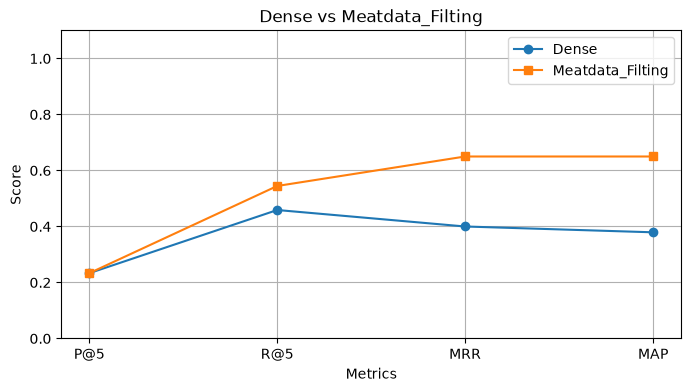

In [19]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
original_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
compressed_vals = [self_query_metrics['P@k'], self_query_metrics['R@k'], self_query_metrics['MRR'], self_query_metrics['MAP']]

x = range(len(metrics))  # 0~3

plt.figure(figsize=(8, 4))
plt.plot(x, original_vals, marker='o', label='Dense')
plt.plot(x, compressed_vals, marker='s', label='Meatdata_Filting')
plt.xticks(x, metrics)  # x축 눈금은 0~3 -> 지표명
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Dense vs Meatdata_Filting')
plt.legend()
plt.grid()
plt.show()

## 왜 이런 결과가 나왔나?

- **Dense Retrieval**
  - 문서의 **의미적 유사도**만을 기준으로 판단
  - 작성자(author), 카테고리(category)와 같은 **구조적 조건을 직접 반영하지 못함**

- **Self-Query Retriever (Metadata 기반)**
  - 자연어 질의에서 **조건을 자동으로 추출**
  - 추출된 조건을 **메타데이터 필터로 강제 적용**하여 검색

예를 들어,

> **“이영희가 쓴 여행 관련 글”**

과 같은 질의는  
- Dense Retrieval에게는 의미적으로 **모호한 질문**이지만  
- Metadata 검색에게는 **명확한 조건 기반 질의**가 된다.

---

## 실무 결론 (중요)

### 권장 검색 파이프라인
Self-Query / Metadata Filtering  
↓
Dense Retrieval  
↓
ReRank (선택)

- **조건이 명확한 질의** → Metadata 검색 우선
- **의미적 탐색 중심 질의** → Dense Retrieval 활용
- **실제 서비스 환경** → 두 방식을 결합한 Hybrid 전략 적용

---

## 한 줄 결론 (교안 / 발표용)

> **구조적 조건이 포함된 질의에서는 Dense Retrieval보다 Metadata 기반 검색이 압도적으로 높은 정확도를 보인다.**